In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from evaluation.probes.svm import SVMProbe


In [14]:
rng = np.random.default_rng()
n_sample = 1000
x_train = rng.normal(size=(n_sample, 1024))
x_val = rng.normal(size=(n_sample, 1024))
y_train = np.sign(rng.normal(size=(n_sample)))
y_val = np.sign(rng.normal(size=(n_sample,)))

In [16]:
probe = SVMProbe(
    task_type='cls',
    task_name='test',
    fold_index=0,
    output_dir='./',
    filename_prefix='test_run',
    enable_plots=False,
    C_start_end=[1e-6, 1e6],
    kernel_gamma_start_end=[1e-6, 1e1],
    kernel_degree_start_end=1,
    opt_n_iter=20,
    opt_n_jobs=4,
    opt_n_points=1,
)

In [17]:
fold_results = probe.fit(x_train, y_train, x_val, y_val)

In [ ]:
fold_results

FoldResult(train_loss=[17.661390160667402], val_loss=[16.471949598826537], metric_history=[0.7038237200259235], best_metric=0.7038237200259235, best_model_state={'C': 5.87540411933884e-05, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 1, 'gamma': 0.001948086705393068, 'kernel': 'poly', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}, model=SVC(C=5.87540411933884e-05, degree=1, gamma=0.001948086705393068, kernel='poly'))

<BarContainer object of 1024 artists>

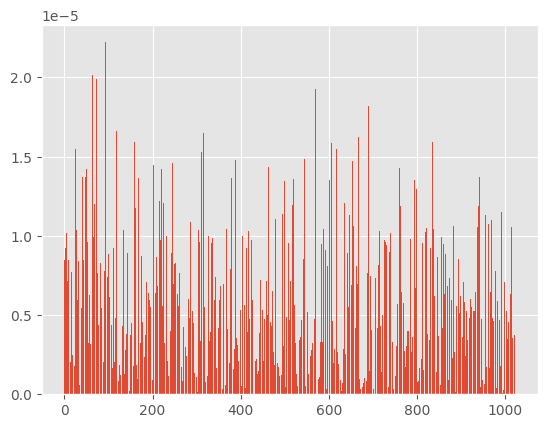

In [16]:
feat_importance, feat_names, sort_order = fold_results.explainer.feature_importance(sort=False, include_intercept=False)

plt.bar(x=np.arange(len(feat_importance)), height=feat_importance)

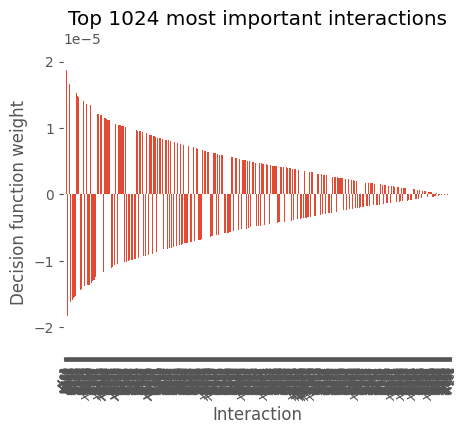

In [10]:
fold_results.explainer.plot_model_bar(n_features=1024)

In [8]:
assert 'c' in ['a','b']

AssertionError: 